In [1]:
# read the table, plot the top 10 most significant and not redundant functions

In [2]:
import pandas, numpy

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
enrichments_file = '/Users/adrian/research/bmcbf/025_isafjordur/results/002_DEGs/clusterProfiler_enrichments_sets.tsv'

In [5]:
df = pandas.read_csv(enrichments_file, sep='\t')
df

,Cluster,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count,transformed_ids
1,skmel up,R-HSA-1474244,Extracellular matrix organization,64/543,300/11146,0.213333,4.379030,13.425901,1.566266e-24,1.705664e-21,1.600889e-21,5033/4921/4325/9672/1462/3690/3672/1508/10536/...,64,"ADAM19, ADAMTS9, BMP2, CD151, CD44, COL11A2, C..."
2,skmel up,R-HSA-1474290,Collagen formation,27/543,90/11146,0.300000,6.158011,11.118087,7.583294e-15,4.129104e-12,3.875463e-12,5033/1508/10536/3914/1307/667/1287/64175/16904...,27,"CD151, COL11A2, COL15A1, COL16A1, COL18A1, COL..."
3,skmel up,R-HSA-3560782,Diseases associated with glycosaminoglycan met...,18/543,41/11146,0.439024,9.011723,11.630119,1.287132e-13,4.672290e-11,4.385282e-11,4166/2239/9672/1462/11285/2817/3339/22856/1464...,18,"B3GAT3, B4GALT7, CHST6, CHSY1, CSPG4, DCN, EXT..."
4,skmel up,R-HSA-1630316,Glycosaminoglycan metabolism,30/543,126/11146,0.238095,4.887310,9.930458,2.188510e-13,5.958218e-11,5.592219e-11,79411/4166/2239/9672/1462/11285/2817/2799/3339...,30,"B3GAT3, B4GALT7, CD44, CEMIP, CHST2, CHST6, CH..."
5,skmel up,R-HSA-3560783,"Defective B4GALT7 causes EDS, progeroid type",12/543,20/11146,0.600000,12.316022,11.462117,1.398084e-11,2.537522e-09,2.381648e-09,2239/9672/1462/11285/2817/3339/1464/6383/2719/...,12,"B4GALT7, CSPG4, DCN, GPC1, GPC3, GPC4, GPC6, H..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,u2os down,R-HSA-69239,Synthesis of DNA,11/296,120/11146,0.091667,3.451745,4.459930,3.418895e-04,1.759917e-02,1.655465e-02,2237/4998/9134/81620/7321/6118/5558/9837/4173/...,11,"CCNE2, CDT1, FEN1, GINS1, MCM4, ORC1, PRIM2, P..."
89,u2os down,R-HSA-9675135,Diseases of DNA repair,7/296,51/11146,0.137255,5.168389,4.927886,3.687913e-04,1.812106e-02,1.704557e-02,675/5932/6118/5888/672/7156/7516,7,"BRCA1, BRCA2, RAD51, RBBP8, RPA2, TOP3A, XRCC2"
90,u2os down,R-HSA-69206,G1/S Transition,11/296,131/11146,0.083969,3.161904,4.111032,7.224302e-04,3.395422e-02,3.193902e-02,4998/7465/9134/81620/5933/6118/5558/55388/4173...,11,"CCNE2, CDT1, MCM10, MCM4, MYC, ORC1, PRIM2, PS..."
91,u2os down,R-HSA-69620,Cell Cycle Checkpoints,18/296,292/11146,0.061644,2.321224,3.778713,7.956892e-04,3.583917e-02,3.371210e-02,4998/5932/9577/55055/7465/9134/7321/6118/79682...,18,"BABAM2, BRCA1, CCNE2, CENPQ, CENPU, CLSPN, ITG..."


In [6]:
contrasts = []
for element in df['Cluster']:
    if element not in contrasts:
        contrasts.append(element)

print(contrasts)

['skmel up', 'skmel down', 'intersect up', 'intersect down', 'u2os up', 'u2os down']


In [7]:
terms_to_use = []
for contrast in contrasts:
    
    print(contrast)
    sub = df[df['Cluster'] == contrast]
    all_observed_gene_lists = []
    contrast_terms = []
    
    for index, row in sub.iterrows():
        
        
        genes = row['transformed_ids'].split(',')
        #print('\t', row['ID'], row['Description'], len(genes))
        
        # checking the overlap
        overlap = False
        max_overlap = 0
        for element in all_observed_gene_lists:
            intersect = list(set(element) & set(genes))
            relative_intersect = len(intersect)/len(genes)
            #print('\t\t\t intersect is', len(intersect), relative_intersect)
            if max_overlap < relative_intersect:
                max_overlap = relative_intersect
            if relative_intersect > 0.9:
                overlap=True
            
        all_observed_gene_lists.append(genes)

        #print('\t', overlap)
        #print()
        if overlap == False:
            print(row['ID'], row['Description'], max_overlap)
            if len(contrast_terms) < 10:
                contrast_terms.append(row['ID'])
        else:
            print('\t\t', row['ID'], row['Description'], max_overlap)

    # end of contrast
    terms_to_use.append(contrast_terms)
    print()

skmel up
R-HSA-1474244 Extracellular matrix organization 0
		 R-HSA-1474290 Collagen formation 0.9629629629629629
R-HSA-3560782 Diseases associated with glycosaminoglycan metabolism 0.3333333333333333
R-HSA-1630316 Glycosaminoglycan metabolism 0.6
		 R-HSA-3560783 Defective B4GALT7 causes EDS, progeroid type 0.9166666666666666
		 R-HSA-3560801 Defective B3GAT3 causes JDSSDHD 1.0
		 R-HSA-3000171 Non-integrin membrane-ECM interactions 0.9473684210526315
		 R-HSA-1971475 A tetrasaccharide linker sequence is required for GAG synthesis 1.0
		 R-HSA-1638091 Heparan sulfate/heparin (HS-GAG) metabolism 1.0
		 R-HSA-2022090 Assembly of collagen fibrils and other multimeric structures 1.0
		 R-HSA-4420332 Defective B3GALT6 causes EDSP2 and SEMDJL1 0.9090909090909091
		 R-HSA-216083 Integrin cell surface interactions 0.9523809523809523
R-HSA-3656237 Defective EXT2 causes exostoses 2 0.8888888888888888
		 R-HSA-3656253 Defective EXT1 causes exostoses 1, TRPS2 and CHDS 1.0
		 R-HSA-3000157 Laminin

In [8]:
#df[(df['ID'] == element) & (df['Cluster'] == terms_to_use[i])]
terms_to_use

[['R-HSA-1474244',
  'R-HSA-3560782',
  'R-HSA-1630316',
  'R-HSA-3656237',
  'R-HSA-71387',
  'R-HSA-9694614',
  'R-HSA-3000170',
  'R-HSA-3781865',
  'R-HSA-9820960',
  'R-HSA-6785807'],
 ['R-HSA-9856651', 'R-HSA-9730414', 'R-HSA-9824585'],
 ['R-HSA-1474244',
  'R-HSA-3000178',
  'R-HSA-4641263',
  'R-HSA-1793185',
  'R-HSA-3000171'],
 ['R-HSA-71288'],
 ['R-HSA-112316', 'R-HSA-397014', 'R-HSA-8873719', 'R-HSA-3906995'],
 ['R-HSA-9709603',
  'R-HSA-5693568',
  'R-HSA-5693616',
  'R-HSA-5693538',
  'R-HSA-5685942',
  'R-HSA-69242',
  'R-HSA-69190',
  'R-HSA-68962',
  'R-HSA-69206',
  'R-HSA-69620']]

R-HSA-1474244 64
R-HSA-3560782 18
R-HSA-1630316 30
R-HSA-3656237 9
R-HSA-71387 38
R-HSA-9694614 9
R-HSA-3000170 10
R-HSA-3781865 23
R-HSA-9820960 9
R-HSA-6785807 19
R-HSA-9856651 15
R-HSA-9730414 17
R-HSA-9824585 9
R-HSA-1474244 16
R-HSA-3000178 7
R-HSA-4641263 4
R-HSA-1793185 5
R-HSA-3000171 5
R-HSA-71288 3
R-HSA-112316 44
R-HSA-397014 27
R-HSA-8873719 10
R-HSA-3906995 10
R-HSA-9709603 6
R-HSA-5693568 7
R-HSA-5693616 7
R-HSA-5693538 13
R-HSA-5685942 9
R-HSA-69242 14
R-HSA-69190 6
R-HSA-68962 6
R-HSA-69206 11
R-HSA-69620 18
Extracellular matrix organization
Diseases associated with glycosaminoglycan metabolism
Glycosaminoglycan metabolism
Defective EXT2 causes exostoses 2
Metabolism of carbohydrates
Attachment and Entry
Syndecan interactions
Diseases of glycosylation
Respiratory syncytial virus (RSV) attachment and entry
Interleukin-4 and Interleukin-13 signaling
MITF-M-dependent gene expression
MITF-M-regulated melanocyte development
Regulation of MITF-M-dependent genes involved in pi

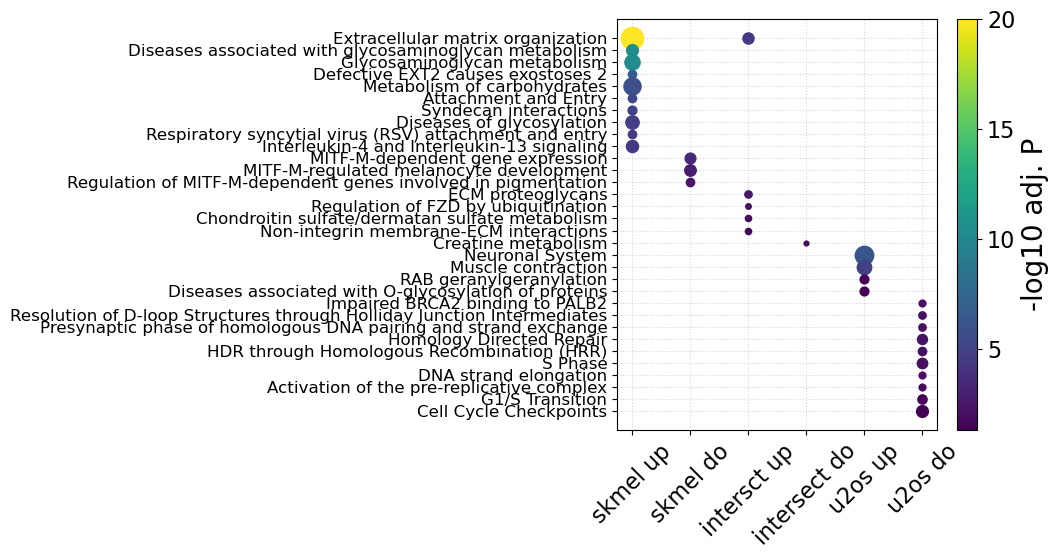

In [13]:
terms_used_so_far = {}
depth = 0
for i in range(len(terms_to_use)):
    for j in range(len(terms_to_use[i])):
       
        element = terms_to_use[i][j]
        
        if element in terms_used_so_far.keys():
            location = terms_used_so_far[element]
        else:
            depth = depth - 1
            location = depth

        # define color
        adjp = -numpy.log10(df[(df['ID'] == element) & (df['Cluster'] == contrasts[i])]['p.adjust'].values[0])
        #print(element, adjp)

        # define size
        thesize = int(df[(df['ID'] == element) & (df['Cluster'] == contrasts[i])]['GeneRatio'].values[0].split('/')[0])
        print(element, thesize)
        
        # make a point        
        matplotlib.pyplot.scatter(i, location, s=thesize*4, c=adjp, zorder=9999, cmap='viridis', vmin=-numpy.log10(0.05), vmax=20)
        #matplotlib.pyplot.text(i, location, terms_to_use[i][j], fontsize=10)

        terms_used_so_far[element] = location


#matplotlib.pyplot.ylim(-12, 0)
matplotlib.pyplot.colorbar(label='-log10 adj. P', ticks=[5, 10, 15, 20])

# close the figure
a = []; b = []
for element in terms_used_so_far.keys():
    description = list(df[df['ID'] == element]['Description'].values)[0]
    a.append(description)
    b.append(terms_used_so_far[element])
matplotlib.pyplot.yticks(b, a, fontsize=12)
for element in a:
    print(element)

#labelsa = ['s up', 's do', 'i up', 'i do', 'u up', 'u do']
#matplotlib.pyplot.xticks([0, 1, 2, 3, 4, 5], labelsa)

labelsb = ['skmel up', 'skmel do', 'intersct up', 'intersect do', 'u2os up', 'u2os do']
matplotlib.pyplot.xticks([0, 1, 2, 3, 4, 5], labelsb, rotation=45)

matplotlib.pyplot.xlim(-0.25, 5.25)
matplotlib.pyplot.grid(ls=':', alpha=0.5)
matplotlib.pyplot.tight_layout()

#matplotlib.pyplot.show()
matplotlib.pyplot.savefig('enrichment.svg')

In [10]:
terms_used_so_far

{'R-HSA-1474244': -1,
 'R-HSA-3560782': -2,
 'R-HSA-1630316': -3,
 'R-HSA-3656237': -4,
 'R-HSA-71387': -5,
 'R-HSA-9694614': -6,
 'R-HSA-3000170': -7,
 'R-HSA-3781865': -8,
 'R-HSA-9820960': -9,
 'R-HSA-6785807': -10,
 'R-HSA-9856651': -11,
 'R-HSA-9730414': -12,
 'R-HSA-9824585': -13,
 'R-HSA-3000178': -14,
 'R-HSA-4641263': -15,
 'R-HSA-1793185': -16,
 'R-HSA-3000171': -17,
 'R-HSA-71288': -18,
 'R-HSA-112316': -19,
 'R-HSA-397014': -20,
 'R-HSA-8873719': -21,
 'R-HSA-3906995': -22,
 'R-HSA-9709603': -23,
 'R-HSA-5693568': -24,
 'R-HSA-5693616': -25,
 'R-HSA-5693538': -26,
 'R-HSA-5685942': -27,
 'R-HSA-69242': -28,
 'R-HSA-69190': -29,
 'R-HSA-68962': -30,
 'R-HSA-69206': -31,
 'R-HSA-69620': -32}

In [11]:
terms_used_so_far.keys()

dict_keys(['R-HSA-1474244', 'R-HSA-3560782', 'R-HSA-1630316', 'R-HSA-3656237', 'R-HSA-71387', 'R-HSA-9694614', 'R-HSA-3000170', 'R-HSA-3781865', 'R-HSA-9820960', 'R-HSA-6785807', 'R-HSA-9856651', 'R-HSA-9730414', 'R-HSA-9824585', 'R-HSA-3000178', 'R-HSA-4641263', 'R-HSA-1793185', 'R-HSA-3000171', 'R-HSA-71288', 'R-HSA-112316', 'R-HSA-397014', 'R-HSA-8873719', 'R-HSA-3906995', 'R-HSA-9709603', 'R-HSA-5693568', 'R-HSA-5693616', 'R-HSA-5693538', 'R-HSA-5685942', 'R-HSA-69242', 'R-HSA-69190', 'R-HSA-68962', 'R-HSA-69206', 'R-HSA-69620'])

In [12]:
list(df[df['ID'] == 'R-HSA-1474244']['Description'].values)[0]

'Extracellular matrix organization'